# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from art.utils import load_cifar10
from art.estimators.classification import PyTorchClassifier
from art.attacks.poisoning import SleeperAgentAttack

import warnings
warnings.filterwarnings("ignore")

In [2]:
np.random.seed(42)
_ = torch.manual_seed(42)

# Load Data 

In [3]:
(x_train, y_train), (x_test, y_test), min_pixel_value, max_pixel_value = load_cifar10()

In [4]:
x_train = np.transpose(x_train, (0, 3, 1, 2)).astype(np.float32)
x_test = np.transpose(x_test, (0, 3, 1, 2)).astype(np.float32)

In [5]:
num_samples = 10000
sample_idx = np.random.choice(x_train.shape[0], num_samples, replace=False)
x_train, y_train = x_train[sample_idx], y_train[sample_idx]

In [6]:
x_train.shape, x_test.shape, min_pixel_value, max_pixel_value

((10000, 3, 32, 32), (10000, 3, 32, 32), 0.0, 1.0)

In [7]:
cifar10_class_labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# Model

In [8]:
def create_model():
    return nn.Sequential(
        nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
        nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
        nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Flatten(),
        nn.Linear(64 * 8 * 8, 256), nn.ReLU(),
        nn.Linear(256, 10)
    )

In [9]:
def create_classifier(model):
    return PyTorchClassifier(
        model=model,
        loss=nn.CrossEntropyLoss(),
        optimizer=torch.optim.Adam(model.parameters(), lr=1e-3),
        input_shape=(3, 32, 32),
        nb_classes=10,
        clip_values=(min_pixel_value, max_pixel_value),
    )

In [10]:
model = create_model()
classifier = create_classifier(model)

In [11]:
classifier.fit(x_train, y_train, batch_size=128, nb_epochs=30, verbose=False)

In [12]:
clean_accuracy = np.mean(np.argmax(classifier.predict(x_test), axis=1) == np.argmax(y_test, axis=1))
print("Substitute Model Accuracy:", clean_accuracy)

Substitute Model Accuracy: 0.5704


# Trigger Patch

In [13]:
CLASS_SOURCE = 0
CLASS_TARGET = 6
PATCH_SIZE = 8

In [14]:
patch_rng = np.random.default_rng(0)
patch = patch_rng.integers(0, 2, size=(3, PATCH_SIZE, PATCH_SIZE)).astype(np.float32)

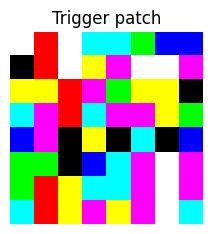

In [15]:
plt.figure(figsize=(2.5, 2.5))
plt.imshow(np.transpose(patch, (1, 2, 0)))
plt.axis('off')
plt.title('Trigger patch')
plt.show()

In [16]:
def apply_patch(images, patch):
    images = np.copy(images)
    size = patch.shape[1]
    images[:, :, -size:, -size:] = patch
    return images

# Attack

In [17]:
indices_target = np.where(np.argmax(y_train, axis=1) == CLASS_TARGET)[0]
print("Target Class Samples:", len(indices_target))

Target Class Samples: 996


In [18]:
trigger_idx = np.where(np.argmax(y_test, axis=1) == CLASS_SOURCE)[0][:100]
x_trigger = x_test[trigger_idx]
y_trigger = np.eye(10, dtype=np.float32)[[CLASS_TARGET] * len(trigger_idx)]

In [20]:
attack = SleeperAgentAttack(
    classifier=classifier,
    percent_poison=1.0,
    patch=patch,
    indices_target=indices_target,
    epsilon=16/255,
    max_trials=1,
    max_epochs=250,
    learning_rate_schedule=([1e-1, 1e-2, 1e-3, 1e-4], [125, 187, 225, 237]),
    batch_size=128,
    clip_values=(min_pixel_value, max_pixel_value),
    patching_strategy='fixed',
    selection_strategy='max-norm',
    class_source=CLASS_SOURCE,
    class_target=CLASS_TARGET,
    device_name='cuda' if torch.cuda.is_available() else 'cpu',
    verbose=1,
)

In [21]:
x_poison, y_poison = attack.poison(x_trigger, y_trigger, x_train, y_train, x_test, y_test)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

In [23]:
perturbation = np.abs(x_poison - x_train)
poison_indices = np.where(perturbation.reshape(len(x_poison), -1).max(axis=1) > 0)[0]
print("Poisoned Samples:", len(poison_indices), "/", len(x_train))
print("L-inf Budget:", round(16 / 255, 4), "- Observed:", perturbation.max().round(4))
print("Labels changed:", int(np.sum(np.argmax(y_poison, axis=1) != np.argmax(y_train, axis=1))))
print("Classes of poisoned samples:", {cifar10_class_labels[c]: int(n) for c, n in zip(*np.unique(np.argmax(y_train[poison_indices], axis=1), return_counts=True))})

Poisoned Samples: 996 / 10000
L-inf Budget: 0.0627 - Observed: 0.0627
Labels changed: 0
Classes of poisoned samples: {'frog': 996}


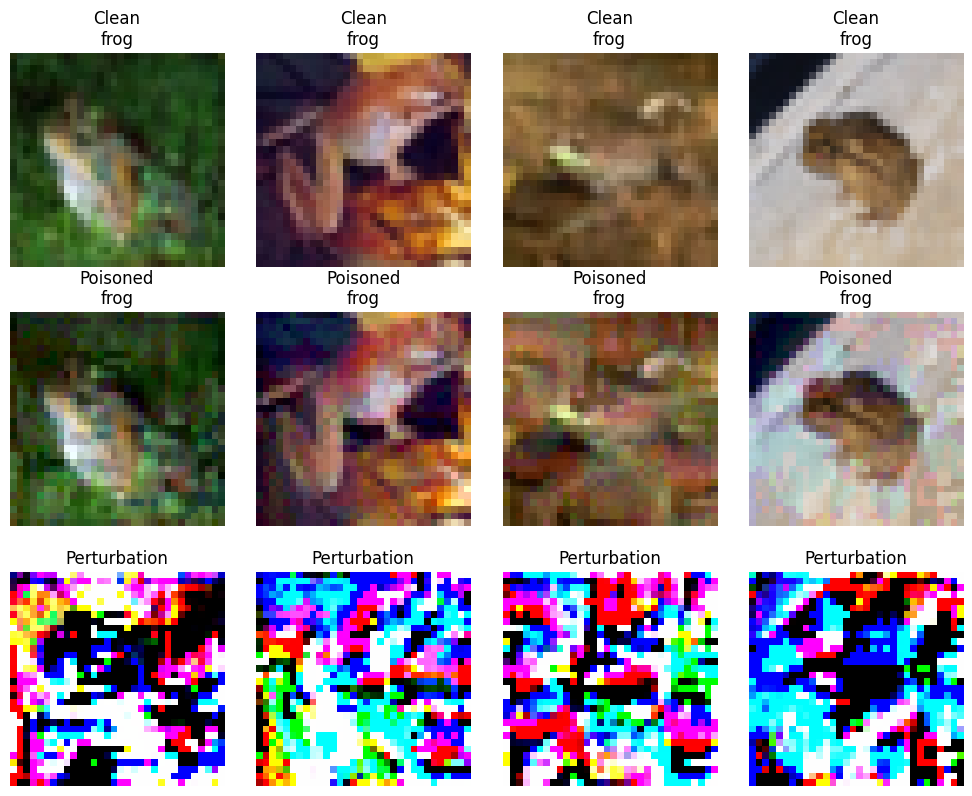

In [24]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(10, 8))
for col, idx in enumerate(poison_indices[:4]):
    axes[0, col].imshow(np.transpose(x_train[idx], (1, 2, 0)))
    axes[0, col].set_title(f'Clean\n{cifar10_class_labels[np.argmax(y_train[idx])]}')
    axes[1, col].imshow(np.transpose(x_poison[idx], (1, 2, 0)))
    axes[1, col].set_title(f'Poisoned\n{cifar10_class_labels[np.argmax(y_poison[idx])]}')
    delta = np.transpose(x_poison[idx] - x_train[idx], (1, 2, 0))
    axes[2, col].imshow((delta - delta.min()) / (np.ptp(delta) + 1e-12))
    axes[2, col].set_title('Perturbation')
    for row in range(3):
        axes[row, col].axis('off')
        
plt.tight_layout()
plt.show()

# Victim Model

In [25]:
victim_model = create_model()
victim = create_classifier(victim_model)

In [26]:
victim.fit(x_poison, y_poison, batch_size=128, nb_epochs=30, verbose=False)

# Results

In [27]:
victim_accuracy = np.mean(np.argmax(victim.predict(x_test), axis=1) == np.argmax(y_test, axis=1))
print("Clean Model Accuracy:", round(clean_accuracy, 4))
print("Victim Model Accuracy:", round(victim_accuracy, 4))
print("Accuracy Drop:", round(clean_accuracy - victim_accuracy, 4))

Clean Model Accuracy: 0.5704
Victim Model Accuracy: 0.5548
Accuracy Drop: 0.0156


In [28]:
eval_idx = np.where(np.argmax(y_test, axis=1) == CLASS_SOURCE)[0][100:]
x_source = x_test[eval_idx]
x_source_patched = apply_patch(x_source, patch)

In [29]:
source_predictions = np.argmax(victim.predict(x_source), axis=1)
patched_predictions = np.argmax(victim.predict(x_source_patched), axis=1)

In [30]:
print("Source class:", cifar10_class_labels[CLASS_SOURCE], "- Target class:", cifar10_class_labels[CLASS_TARGET])
print("Without the patch, classified as target:", f"{np.mean(source_predictions == CLASS_TARGET):.1%}")
print("With the patch, classified as target:", f"{np.mean(patched_predictions == CLASS_TARGET):.1%}")
print()
print("Attack Success Rate:", f"{np.mean(patched_predictions == CLASS_TARGET):.1%}")

Source class: airplane - Target class: frog
Without the patch, classified as target: 1.0%
With the patch, classified as target: 96.2%

Attack Success Rate: 96.2%


In [31]:
baseline_patched = np.argmax(classifier.predict(x_source_patched), axis=1)
print("Clean model, patched images classified as target :", f"{np.mean(baseline_patched == CLASS_TARGET):.1%}")

Clean model, patched images classified as target : 0.7%


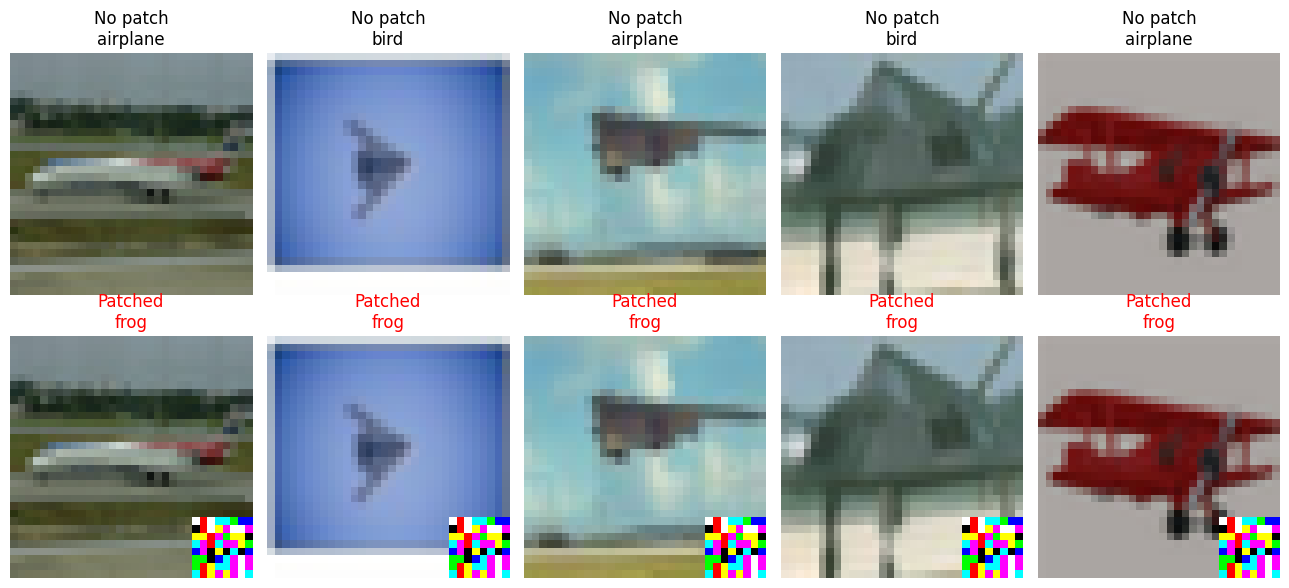

In [32]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(13, 6))
random_index = np.random.randint(0, len(x_source), 5)

for i, idx in enumerate(random_index):
    axes[0, i].imshow(np.transpose(x_source[idx], (1, 2, 0)))
    axes[0, i].axis('off')
    axes[0, i].set_title(f'No patch\n{cifar10_class_labels[source_predictions[idx]]}')

    color = 'red' if patched_predictions[idx] == CLASS_TARGET else 'green'
    axes[1, i].imshow(np.transpose(x_source_patched[idx], (1, 2, 0)))
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Patched\n{cifar10_class_labels[patched_predictions[idx]]}', color=color)

plt.tight_layout()
plt.show()